<a href="https://colab.research.google.com/github/khushikumari936/Book_AI/blob/main/Market_Sentiment_vs_Trader_Behavior_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#charts
sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [ ]:
sentiment = pd.read_csv('historical_data.csv')
trades = pd.read_csv('fear_greed_index.csv')
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)
trades.head()
sentiment.head()

Sentiment Shape: (211224, 16)
Trades Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower()

In [ ]:
# Trades date
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='s')
trades['date'] = trades['timestamp'].dt.date
# Sentiment date
sentiment['date'] = pd.to_datetime(sentiment['timestamp ist'], format='%d-%m-%Y %H:%M').dt.date

In [ ]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

# Drop if needed
trades = trades.dropna()
sentiment = sentiment.dropna()

timestamp         0
value             0
classification    0
date              0
dtype: int64
account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
date                0
dtype: int64


In [ ]:
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()
merged = pd.merge(sentiment, trades[['date', 'classification']], on='date', how='inner')
merged.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [ ]:
# Win / Loss
merged['win'] = merged['closed pnl'] > 0

# Absolute risk
merged['abs_pnl'] = abs(merged['closed pnl'])

# Trade direction
merged['is_long'] = merged['side'].str.lower() == 'buy'
daily_metrics = merged.groupby(['date', 'classification']).agg({
    'closed pnl': 'sum',
    'win': 'mean',
    'size usd': 'mean',
    'account': 'count'
}).reset_index()

daily_metrics.rename(columns={
    'closed pnl': 'daily_pnl',
    'win': 'win_rate',
    'account': 'num_trades'
}, inplace=True)
ls_ratio = merged.groupby(['date', 'classification', 'side']).size().unstack(fill_value=0)
ls_ratio['long_short_ratio'] = ls_ratio.get('BUY',1) / ls_ratio.get('SELL',1)

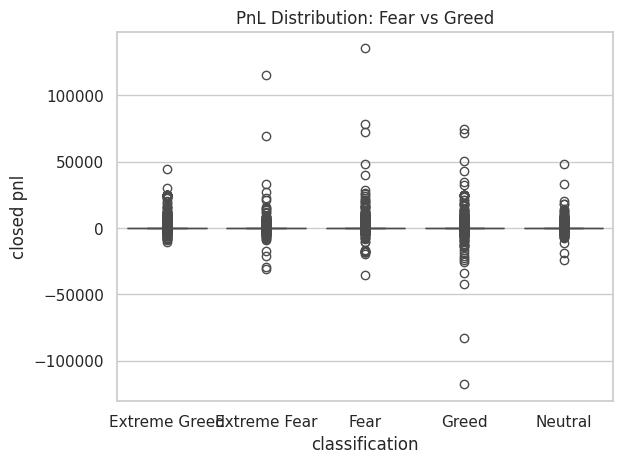

In [ ]:
#Q1Does performance differ in Fear vs Greed?
sns.boxplot(x='classification', y='closed pnl', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

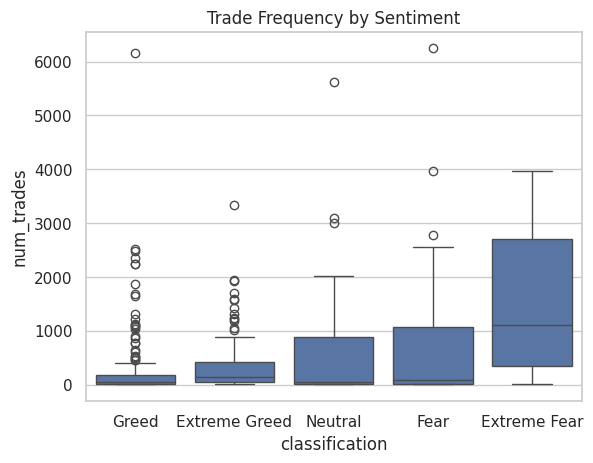

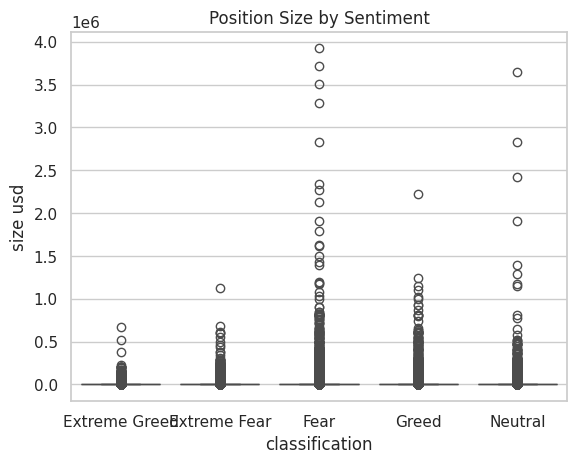

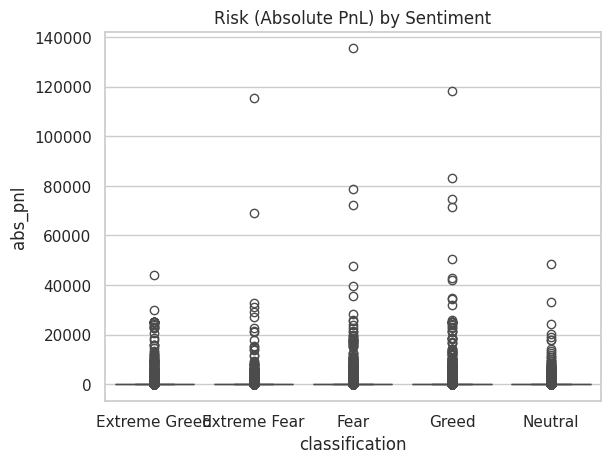

In [ ]:
#Q2: Do traders behave differently?
sns.boxplot(x='classification', y='num_trades', data=daily_metrics)
plt.title("Trade Frequency by Sentiment")
plt.show()
#Position size
sns.boxplot(x='classification', y='size usd', data=merged)
plt.title("Position Size by Sentiment")
plt.show()
#Risk Behaviour
sns.boxplot(x='classification', y='abs_pnl', data=merged)
plt.title("Risk (Absolute PnL) by Sentiment")
plt.show()

In [ ]:
#Segment 1: High vs Low Activity Traders
trade_counts = merged['account'].value_counts()

merged['trader_type'] = merged['account'].map(
    lambda x: 'High Activity' if trade_counts[x] > trade_counts.median() else 'Low Activity'
)
#Segment 2: Winners vs Losers
total_pnl = merged.groupby('account')['closed pnl'].sum()

merged['pnl_group'] = merged['account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)
seg_analysis = merged.groupby(['classification', 'trader_type'])['closed pnl'].mean().unstack()
print(seg_analysis)

trader_type     High Activity  Low Activity
classification                             
Extreme Fear        34.163353     35.941979
Extreme Greed       62.870911    103.264685
Fear                51.323784     80.835791
Greed               25.004641    210.210287
Neutral             34.579701     31.845656


In [ ]:
print("Final Dataset Shape:", merged.shape)
print("Unique Traders:", merged['account'].nunique())

Final Dataset Shape: (211218, 23)
Unique Traders: 32
